# Quickstart

This notebook walks through your first SUPERMag calculation: computing the
critical temperature $T_c$ of a superconductor/ferromagnet bilayer as a
function of the ferromagnet thickness $d_F$.

## Installation

Install the package from PyPI (or from source):

```bash
pip install supermag
```

## Step 1: Load Material Parameters

SUPERMag ships with a built-in database of common superconductors and
ferromagnets. Use `get_material()` to look up parameters.

In [2]:
import sys
sys.path.insert(0, r"c:\Users\seans\Documents\GitHub\SUPERMag-Simulation-Suite\python")

import supermag

nb = supermag.get_material("Nb")
fe = supermag.get_material("Fe")

print("Niobium (superconductor):")
for k, v in nb.items():
    print(f"  {k}: {v}")

print("\nIron (ferromagnet):")
for k, v in fe.items():
    print(f"  {k}: {v}")

Niobium (superconductor):
  type: superconductor
  Tc: 9.2
  xi_S: 38.0
  lambda_L: 39.0
  Delta_0: 1.55

Iron (ferromagnet):
  type: ferromagnet
  E_ex: 256.0
  xi_F: 0.7
  D_F: 0.00025


## Step 2: Compute $T_c$ vs $d_F$

The key function is `supermag.critical_temperature()`. It solves the
digamma self-consistency equation to find the critical temperature as
the F-layer thickness varies.

The main parameters are:

| Parameter | Meaning | Units |
|-----------|---------|-------|
| `Tc0` | Bulk $T_c$ of the superconductor | K |
| `d_S` | S-layer thickness | nm |
| `d_F_array` | Array of F-layer thicknesses | nm |
| `E_ex` | Exchange energy of the ferromagnet | meV |
| `xi_S` | S coherence length | nm |
| `xi_F` | F coherence length | nm |
| `gamma` | Interface transparency parameter | — |

In [3]:
import numpy as np

# Define the F-layer thickness range
d_F = np.linspace(0.5, 20.0, 100)

# Compute Tc(d_F)
Tc = supermag.critical_temperature(
    Tc0=nb["Tc"],
    d_S=50.0,         # 50 nm Nb layer
    d_F_array=d_F,
    E_ex=fe["E_ex"],
    xi_S=nb["xi_S"],
    xi_F=fe["xi_F"],
    gamma=0.15,
)

print(f"Tc range: {Tc.min():.2f} K to {Tc.max():.2f} K")
print(f"Bulk Tc0 = {nb['Tc']} K")
print(f"Shape: {Tc.shape}")

Tc range: 6.86 K to 7.65 K
Bulk Tc0 = 9.2 K
Shape: (100,)


## Step 3: Plot the Results

SUPERMag includes a convenience plotting function, but you can also
use matplotlib directly.

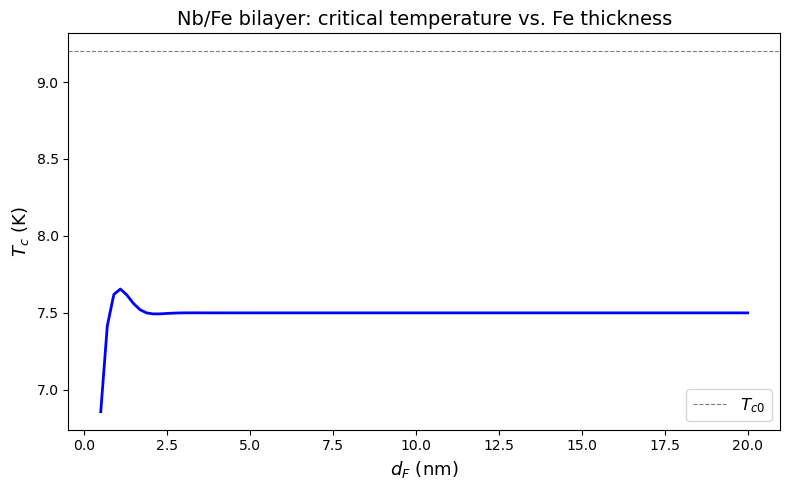

In [4]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(d_F, Tc, 'b-', linewidth=2)
ax.axhline(nb["Tc"], ls="--", color="gray", linewidth=0.8, label=r"$T_{c0}$")
ax.set_xlabel(r"$d_F$ (nm)", fontsize=13)
ax.set_ylabel(r"$T_c$ (K)", fontsize=13)
ax.set_title("Nb/Fe bilayer: critical temperature vs. Fe thickness", fontsize=14)
ax.legend(fontsize=12)
fig.tight_layout()
plt.show()

## Step 4: Apply a Publication Theme

SUPERMag provides built-in matplotlib themes for different contexts.
Apply the `publication` theme for APS/PRB-ready figures.

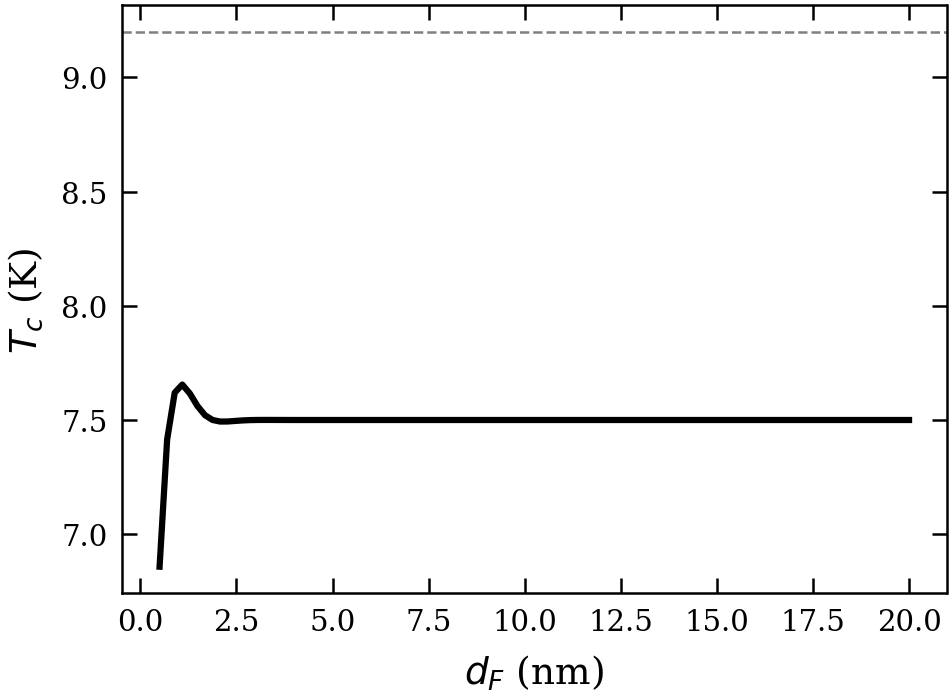

In [5]:
from supermag import apply_theme, theme_context

# Method 1: apply globally
apply_theme("publication")

fig, ax = plt.subplots()
ax.plot(d_F, Tc, linewidth=1.5)
ax.axhline(nb["Tc"], ls="--", color="gray", linewidth=0.6)
ax.set_xlabel(r"$d_F$ (nm)")
ax.set_ylabel(r"$T_c$ (K)")
fig.tight_layout()
plt.show()

# Method 2: use as context manager (reverts when done)
# with theme_context("presentation"):
#     fig, ax = plt.subplots()
#     ...

## Next Steps

- **Parameter sweeps**: See [02_parameter_sweep.ipynb](02_parameter_sweep.ipynb)
  for multi-material comparisons
- **Custom materials**: See [03_custom_materials.ipynb](03_custom_materials.ipynb)
  for defining your own material parameters
- **Theory**: See the theory notebooks in `../theory/` for the equations
  behind the calculations